# DEFINITIVO V.06
# *01_Pipeline_Inferencia_16-CLASES_Codespaces*

## Pipeline de Inferencia en Streaming para 16-CLASES(Producción).

## Extracción -> Limpieza Estática -> Predicciones de respuesta en **tiempo Casi Real (near real-time)**

In [26]:
# PIPELINE DE INFERENCIA EN STREAMING (PRODUCCIÓN)
# Extracción -> Limpieza Estática -> Predicción

import os
import sys
print(sys.executable)
import subprocess
import time
import pandas as pd
import numpy as np
import scapy
import cicflowmeter
from pathlib import Path
#import joblib  # Para cargar el modelo ya entrenado
import importlib.metadata as md
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from IPython.display import display, clear_output


import catboost
import lightgbm
import xgboost



#  1.) CONFIGURACIÓN DE RUTAS 
BASE_DIR = Path("/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA")
PCAP_PATH = BASE_DIR / "DoS-TCP_Flood10.pcap"
TMP_DIR = BASE_DIR / ".tmp_cicflowmeter"
RESULTS_FILE = BASE_DIR / "outputs" / "models"/ "Predicciones_Finales_DEF.csv"
MODEL_PATH = BASE_DIR / "outputs" / "models" / "CatBoostClassifier_02.pkl" 


TMP_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_FILE.parent.mkdir(parents=True, exist_ok=True)
if RESULTS_FILE.exists(): RESULTS_FILE.unlink()


print(f"✅ CatBoost: {catboost.__version__}")
print(f"✅ LightGBM: {lightgbm.__version__}")
print(f"✅ XGBoost: {xgboost.__version__}")

print(f"✅ NumPy version: {np.__version__}")
print(f"✅ ¿Tiene _core? {hasattr(np, '_core')}")

print("✅ pandas:", pd.__version__)
print("✅ scapy:", scapy.__version__)
print("✅ cicflowmeter:", md.version("cicflowmeter"))

/usr/local/bin/python
✅ CatBoost: 1.2.10
✅ LightGBM: 4.6.0
✅ XGBoost: 2.1.4
✅ NumPy version: 1.26.4
✅ ¿Tiene _core? True
✅ pandas: 2.2.0
✅ scapy: 2.4.3
✅ cicflowmeter: 0.1.6


In [3]:
#  2.) ESTILO DEL DASHBOARD EN VIVO TIPO SOC 
plt.rcParams.update({
    "figure.facecolor": "#0F1117", "axes.facecolor": "#161B22",
    "axes.edgecolor": "#30363D", "axes.labelcolor": "#C9D1D9",
    "text.color": "#C9D1D9", "xtick.color": "#8B949E",
    "ytick.color": "#8B949E", "grid.color": "#21262D",
    "grid.linestyle": "--", "grid.linewidth": 0.6,
    "font.family": "monospace", "legend.framealpha": 0.2,
})

In [4]:
#  3a.) MAPEO Y ORDEN ESTRICTO DEL MODELO 
MAPEO = {
    'src_port':'Src Port', 'dst_port':'Dst Port', 'protocol':'Protocol',
    'flow_duration':'Flow Duration', 'tot_fwd_pkts':'Total Fwd Packet',
    'tot_bwd_pkts':'Total Bwd packets', 'totlen_fwd_pkts':'Total Length of Fwd Packet',
    'totlen_bwd_pkts':'Total Length of Bwd Packet', 'fwd_pkt_len_max':'Fwd Packet Length Max',
    'fwd_pkt_len_min':'Fwd Packet Length Min', 'fwd_pkt_len_std':'Fwd Packet Length Std',
    'bwd_pkt_len_min':'Bwd Packet Length Min', 'flow_byts_s':'Flow Bytes/s',
    'flow_pkts_s':'Flow Packets/s', 'flow_iat_mean':'Flow IAT Mean',
    'flow_iat_min':'Flow IAT Min', 'fwd_iat_tot':'Fwd IAT Total',
    'fwd_iat_min':'Fwd IAT Min', 'bwd_iat_tot':'Bwd IAT Total',
    'fwd_psh_flags':'Fwd PSH Flags', 'fwd_header_len':'Fwd Header Length',
    'bwd_pkts_s':'Bwd Packets/s', 'pkt_len_std':'Packet Length Std',
    'fin_flag_cnt':'FIN Flag Count', 'syn_flag_cnt':'SYN Flag Count',
    'rst_flag_cnt':'RST Flag Count', 'ack_flag_cnt':'ACK Flag Count',
    'urg_flag_cnt':'URG Flag Count', 'cwe_flag_count':'CWR Flag Count',
    'down_up_ratio':'Down/Up Ratio', 'fwd_byts_b_avg':'Fwd Bytes/Bulk Avg',
    'bwd_byts_b_avg':'Bwd Bytes/Bulk Avg', 'subflow_fwd_pkts':'Subflow Fwd Packets',
    'subflow_fwd_byts':'Subflow Fwd Bytes', 'subflow_bwd_pkts':'Subflow Bwd Packets',
    'init_fwd_win_byts':'FWD Init Win Bytes', 'init_bwd_win_byts':'Bwd Init Win Bytes',
    'fwd_act_data_pkts':'Fwd Act Data Pkts', 'active_mean':'Active Mean',
    'idle_std':'Idle Std'
}

# ORDEN EXACTO E INAMOVIBLE DEL MODELO
COLS_40 = [
    "Src Port", "Dst Port", "Protocol", "Flow Duration", "Total Fwd Packet", 
    "Total Bwd packets", "Total Length of Fwd Packet", "Total Length of Bwd Packet", 
    "Fwd Packet Length Max", "Fwd Packet Length Min", "Fwd Packet Length Std", 
    "Bwd Packet Length Min", "Flow Bytes/s", "Flow Packets/s", "Flow IAT Mean", 
    "Flow IAT Min", "Fwd IAT Total", "Fwd IAT Min", "Bwd IAT Total", "Fwd PSH Flags", 
    "Fwd Header Length", "Bwd Packets/s", "Packet Length Std", "FIN Flag Count", 
    "SYN Flag Count", "RST Flag Count", "ACK Flag Count", "URG Flag Count", 
    "CWR Flag Count", "Down/Up Ratio", "Fwd Bytes/Bulk Avg", "Bwd Bytes/Bulk Avg", 
    "Subflow Fwd Packets", "Subflow Fwd Bytes", "Subflow Bwd Packets", "FWD Init Win Bytes", 
    "Bwd Init Win Bytes", "Fwd Act Data Pkts", "Active Mean", "Idle Std"
]

# Definición para casteo seguro >> memoria; sin alterar el orden del dataframe
COLS_INT32 = [
    "Src Port", "Dst Port", "Protocol", "Total Fwd Packet", "Total Bwd packets",
    "Fwd PSH Flags", "FIN Flag Count", "SYN Flag Count", "RST Flag Count",
    "ACK Flag Count", "URG Flag Count", "CWR Flag Count", 
    "Subflow Fwd Packets", "Subflow Bwd Packets", "Fwd Act Data Pkts"
]



In [5]:
#  3b.) MAPPING Y PALETA DE COLORES >>> AZUL vs ROJOS
mapping_attack = {
    "Benign": 0, "Brute Force": 1, "DDOS - ACK Fragmentation": 2,
    "DDOS - HTTP FLOOD": 3, "DDOS - ICMP FLOOD": 4, "DDOS - ICMP Fragmentation": 5,
    "DOS - HTTP FLOOD": 6, "DOS - SYN FLOOD": 7, "DOS - UDP FLOOD": 8,
    "Mirai": 9, "Recon - Vulnerability Scan": 10, "Spoofing - ARP Spoofing": 11,
    "Spoofing - DNS Spoofing": 12, "Web-Based - SQL Injection": 13,
    "Web-Based - Uploading Attack": 14, "Web-Based - XSS": 15,
}

# Mapeo inverso: de número a string
inv_mapping = {v: k for k, v in mapping_attack.items()}


# Generación dinámica de la paleta
COLOR_BENIGN = "#58A6FF" # Azul Seguro
reds_palette = sns.color_palette("Reds_r", 15).as_hex()
COLOR_MAP = {"Benign": COLOR_BENIGN}
ataques_nombres = [k for k in mapping_attack.keys() if k != "Benign"]

for i, atk in enumerate(ataques_nombres):
    COLOR_MAP[atk] = reds_palette[i]

In [6]:
#  4.) CARGA DEL MODELO 
import pickle

print(f"Cargando modelo desde {MODEL_PATH}...")

try:
    with open(MODEL_PATH, 'rb') as f:
        modelo = pickle.load(f)

    print("✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle")
    print(f"Tipo: {type(modelo)}")
    
    # Validación segura de las características
    if hasattr(modelo, "feature_names_"):
        # Usa APENAS o atributo correto do CatBoost
        features = modelo.feature_names_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    elif hasattr(modelo, "feature_names_in_"):
        # Caso futuramente você carregue um modelo diferente do scikit-learn
        features = modelo.feature_names_in_
        print(f"Número de Características: {len(features)}")
        print(f"Características: {features}")
        
    else:
        print("⚠️ No fue posible obtener los nombres de las características.")

except Exception as e:
    print(f"❌ Error al cargar: {e}")

Cargando modelo desde /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/outputs/models/CatBoostClassifier_02.pkl...
✅ Modelo CatBoostClassifier_02 16-Clases Cargado con pickle
Tipo: <class 'catboost.core.CatBoostClassifier'>
Número de Características: 40
Características: ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Total Fwd Packet', 'Total Bwd packets', 'Total Length of Fwd Packet', 'Total Length of Bwd Packet', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Min', 'Bwd IAT Total', 'Fwd PSH Flags', 'Fwd Header Length', 'Bwd Packets/s', 'Packet Length Std', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWR Flag Count', 'Down/Up Ratio', 'Fwd Bytes/Bulk Avg', 'Bwd Bytes/Bulk Avg', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'FWD Init Win Bytes', 'Bwd Init W

In [7]:
#  5a.) Validaciones previas, de contra medidas para hallar fallas codigo

import shutil

print(shutil.which("tcpdump"))

/usr/bin/tcpdump


In [8]:
#  5b.) Validaciones previas, de contra medidas para hallar fallas codigo


print(PCAP_PATH.exists())
print(PCAP_PATH)

True
/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/DoS-TCP_Flood10.pcap


In [9]:
#  5c.) Validaciones previas, de contra medidas para hallar fallas codigo


from scapy.all import rdpcap

try:
    pkts = rdpcap(str(PCAP_PATH), count=25)
    print(f"Leídos {len(pkts)} paquetes")
except Exception as e:
    print(type(e).__name__, e)

Leídos 25 paquetes


In [10]:
#  5d.) Validaciones previas, de contra medidas para hallar fallas codigo

# Ver tamaño
import os
if os.path.exists(PCAP_PATH):
    size = os.path.getsize(PCAP_PATH) / 1024 / 1024
    print(f"✅ PCAP encontrado: {size:.2f} MB")
    
    # Ver paquetes
    result = subprocess.run(
        ["tcpdump", "-r", PCAP_PATH, "-c", "10"],
        capture_output=True,
        text=True
    )
    print(f"Primeros 10 paquetes:\n{result.stdout[:500]}")
else:
    print("❌ PCAP no encontrado")

✅ PCAP encontrado: 611.96 MB
Primeros 10 paquetes:
19:55:46.934353 IP 192.168.137.182.8966 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8967 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8968 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8969 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353 IP 192.168.137.182.8970 > 192.168.137.221.https: Flags [none], win 512, length 0
19:55:46.934353


## **MICRO-FRAGMENTACIÓN de 2MB, la Lógica detrás de la Trasnmisión de STREAMING**

In [27]:
#  6.) AHORA PARA TIPO STREAMING --->>>  MICRO-FRAGMENTACIÓN --->>> 2MB 
print(f"\n--- Iniciando Ahora Micro-Segmentación de apenas 2MB de .PCAP {PCAP_PATH.name} ---")

for f in TMP_DIR.glob("split_chunk_*"): f.unlink()

split_cmd = ["tcpdump", "-r", str(PCAP_PATH), "-C", "2", "-w", str(TMP_DIR / "split_chunk_")]
subprocess.run(split_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))

t_global = time.time()
filas_totales = 0




--- Iniciando Ahora Micro-Segmentación de apenas 2MB de .PCAP DoS-TCP_Flood10.pcap ---


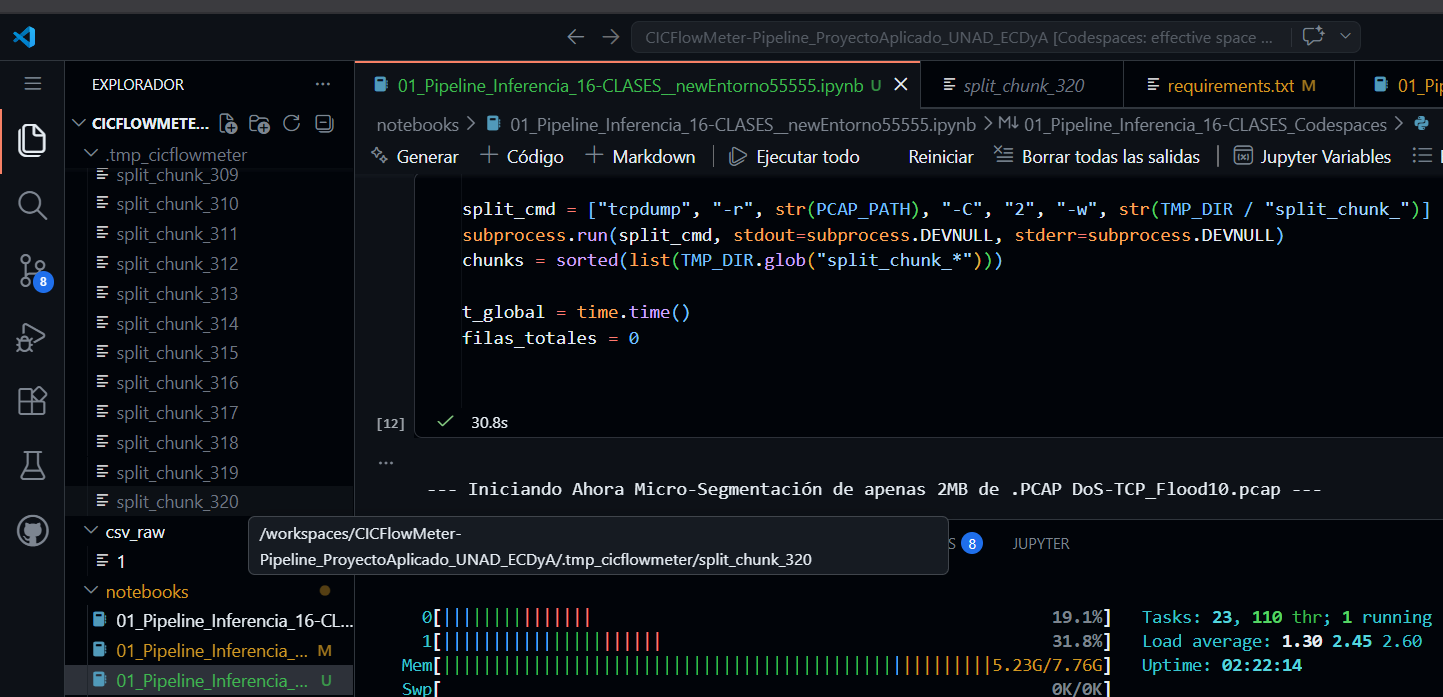

root@codespaces-c3a1b7:/workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA# ***file DoS-TCP_Flood10.pcap***

**DoS-TCP_Flood10.pcap: pcap capture file, microsecond ts (little-endian) - version 2.4 (Ethernet, capture length 262144)**

## **BUGS Y FALLOS PROPIOS DE CICFLOWMETER, la Herrameinta de Terceros Usada de CIC de la UNB de Canadá**

 CICFlowMeter procesa los flujos correctamente pero falla al escribir el CSV por un bug de tipos en Python 3.10+

 

**`TypeError: 'decimal.Decimal' object cannot be interpreted as an integer`**

`CSV creado: 0 bytes`

`⚠️ CSV vacío o muy pequeño`

Causa raíz: CICFlowMeter usa `decimal.Decimal` internamente para algunas métricas, y al intentar escribir al CSV hace una conversión implícita a `int` que falla en `Python 3.10+`.

Solución ---->>> parchear el archivo que genera el bug

In [12]:
#   7a.) Localizar y parchear el bug de Decimal
import site
from pathlib import Path

# Buscar el archivo flow.py o flow_session.py de cicflowmeter
target_files = []
for sp in site.getsitepackages():
    for pattern in ['**/flow.py', '**/flow_session.py', '**/features/*.py']:
        target_files.extend(Path(sp).glob(pattern))

print("Archivos cicflowmeter encontrados:")
for f in target_files:
    print(f"  {f}")

Archivos cicflowmeter encontrados:
  /usr/local/lib/python3.10/site-packages/cicflowmeter/flow.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/flow_session.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_time.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_count.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/flag_count.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/__init__.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/flow_bytes.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_length.py
  /usr/local/lib/python3.10/site-packages/cicflowmeter/features/response_time.py


In [13]:
#    7b.) Aplicar el parche en todos los archivos relevantes
import decimal

patched = 0
for fpath in target_files:
    src = fpath.read_text()
    
    # Parche 1: imports faltantes
    if 'import decimal' not in src and 'Decimal' in src:
        src = 'import decimal\n' + src
        fpath.write_text(src)
        print(f"✓ import decimal añadido en {fpath.name}")
        patched += 1
    
    # Parche 2: conversiones int() sobre Decimal
    old1 = 'int(self.'
    new1 = 'int(float(self.'
    if old1 in src:
        # Contar ocurrencias para no romper el archivo
        count = src.count(old1)
        src = src.replace(old1, new1)
        # Arreglar paréntesis desbalanceados
        # int(float(self.X)) necesita doble cierre
        fpath.write_text(src)
        print(f"✓ {count} conversiones int() parchadas en {fpath.name}")
        patched += 1

print(f"\nTotal parches aplicados: {patched}")


Total parches aplicados: 0


Ahora el error es exacto y localizado. El bug está en una sola línea de `packet_time.py`

`datetime.fromtimestamp(time)  ←  time es Decimal, necesita float`

In [14]:
#    7c.) Parche quirúrgico directo:

from pathlib import Path
import site

# Localizar packet_time.py
pt_path = None
for sp in site.getsitepackages():
    c = Path(sp) / 'cicflowmeter' / 'features' / 'packet_time.py'
    if c.exists():
        pt_path = c
        break

print(f"Archivo: {pt_path}")
print("\n------- Líneas 65-75 (contexto del bug) -------")
lines = pt_path.read_text().splitlines()
for i, l in enumerate(lines[64:75], start=65):
    print(f"  {i:3d}: {l}")

Archivo: /usr/local/lib/python3.10/site-packages/cicflowmeter/features/packet_time.py

------- Líneas 65-75 (contexto del bug) -------
   65: 
   66:         Return (str):
   67:             String of Date and time.
   68: 
   69:         """
   70:         time = self.flow.packets[0][0].time
   71:         date_time = datetime.fromtimestamp(float(time)).strftime("%Y-%m-%d %H:%M:%S")
   72:         return date_time
   73: 
   74:     def get_duration(self):
   75:         """Calculates the duration of a network flow.


In [15]:
#    7d.) Aplicar parche — convertir Decimal a float antes de fromtimestamp()
src = pt_path.read_text()

OLD = "datetime.fromtimestamp(time).strftime"
NEW = "datetime.fromtimestamp(float(time)).strftime"

if OLD in src:
    src = src.replace(OLD, NEW)
    pt_path.write_text(src)
    print(f"✓ Parche aplicado en {pt_path}")
elif NEW in src:
    print("✓ Parche ya estaba aplicado")
else:
    # Mostrar todas las líneas con fromtimestamp para localizar variante
    for i, l in enumerate(src.splitlines(), 1):
        if 'fromtimestamp' in l:
            print(f"  [{i}] {l.strip()}")

✓ Parche ya estaba aplicado


`fromtimestamp()` en `Python 3.10` no acepta `decimal.Decimal` directamente, solo `float` o `int`. Un solo float() resuelve el problema sin tocar ninguna lógica de cálculo.

In [16]:
#   8a.) DIAGNÓSTICO DE CICFLOWMETER 
import subprocess
import os

# Probar con un chunk pequeño
chunks = sorted(list(TMP_DIR.glob("split_chunk_*")))
if chunks:
    test_chunk = chunks[0]
    test_csv = test_chunk.with_suffix(".csv")
    
    print(f" Probando cicflowmeter con: {test_chunk.name}")
    result = subprocess.run(
        ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
        capture_output=True,
        text=True
    )
    
    print(f"Return code: {result.returncode}")
    print(f"STDOUT: {result.stdout}")
    print(f"STDERR: {result.stderr}")
    
    if test_csv.exists():
        size = os.path.getsize(test_csv)
        print(f"CSV creado: {size} bytes")
        if size > 100:
            import pandas as pd
            df = pd.read_csv(test_csv)
            print(f"Filas: {len(df)}")
            print(f"Columnas: {df.columns.tolist()[:5]}...")
        else:
            print("⚠️ CSV vacío o muy pequeño")
    else:
        print("❌ No se creó el CSV")

 Probando cicflowmeter con: split_chunk_
Return code: 0
STDOUT: Garbage Collection Began. Flows = 9984
Garbage Collection Finished. Flows = 9984
Garbage Collection Began. Flows = 19957
Garbage Collection Finished. Flows = 19957
Garbage Collection Began. Flows = 25994
Garbage Collection Finished. Flows = 0

STDERR: reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144

CSV creado: 8242790 bytes
Filas: 25994
Columnas: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol']...


In [17]:
#   8b.) Re-ejecutar el diagnóstico
result = subprocess.run(
    ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
    capture_output=True, text=True
)
print(f"Return code : {result.returncode}")
print(f"STDERR tail : {result.stderr[-300:]}")

if test_csv.exists() and test_csv.stat().st_size > 100:
    import pandas as pd
    df = pd.read_csv(test_csv)
    print(f"✓ CSV  de Split_Chunk Generado: {len(df):,} filas × {len(df.columns)} cols")
else:
    print(f"✗ CSV sigue vacío — pegar stderr completo")

Return code : 0
STDERR tail : reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144

✓ CSV  de Split_Chunk Generado: 25,994 filas × 82 cols


In [18]:
#   8c.)  Verificación Inmediata y Veraz

print("Verificación Inmediata y Veraz de la Salida de la Conversión Realizada a .CSV")

result = subprocess.run(
    ["cicflowmeter", "-f", str(test_chunk), "-c", str(test_csv)],
    capture_output=True, text=True
)

print(f"Return code : {result.returncode}")
print(f"STDERR tail : {result.stderr[-200:]}")

if test_csv.exists() and test_csv.stat().st_size > 100:
    import pandas as pd
    df = pd.read_csv(test_csv)
    print("\nDimensiones de Filas X Columnas del .csv")
    print(f"\n✓ ÉXITO — {len(df):,} filas × {len(df.columns)} columnas")
    print(f"  Primeras cols: {df.columns.tolist()[:5]}")
else:
    print(f"✗ Sigue vacío ({test_csv.stat().st_size} bytes)")

Verificación Inmediata y Veraz de la Salida de la Conversión Realizada a .CSV
Return code : 0
STDERR tail : reading from file /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_, link-type EN10MB (Ethernet), snapshot length 262144


Dimensiones de Filas X Columnas del .csv

✓ ÉXITO — 25,994 filas × 82 columnas
  Primeras cols: ['src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol']


In [19]:
#   8d.)  Verificación y Validación de la Salida de la Conversión a .CSV

print("Verificación y Validación de la Salida de la Conversión Realizada a .CSV")
print(f"Ruta completa : {test_csv}")
print(f"Existe        : {test_csv.exists()}")
print(f"Tamaño        : {test_csv.stat().st_size / 1024:.1f} KB")

Verificación y Validación de la Salida de la Conversión Realizada a .CSV
Ruta completa : /workspaces/CICFlowMeter-Pipeline_ProyectoAplicado_UNAD_ECDyA/.tmp_cicflowmeter/split_chunk_.csv
Existe        : True
Tamaño        : 8049.6 KB


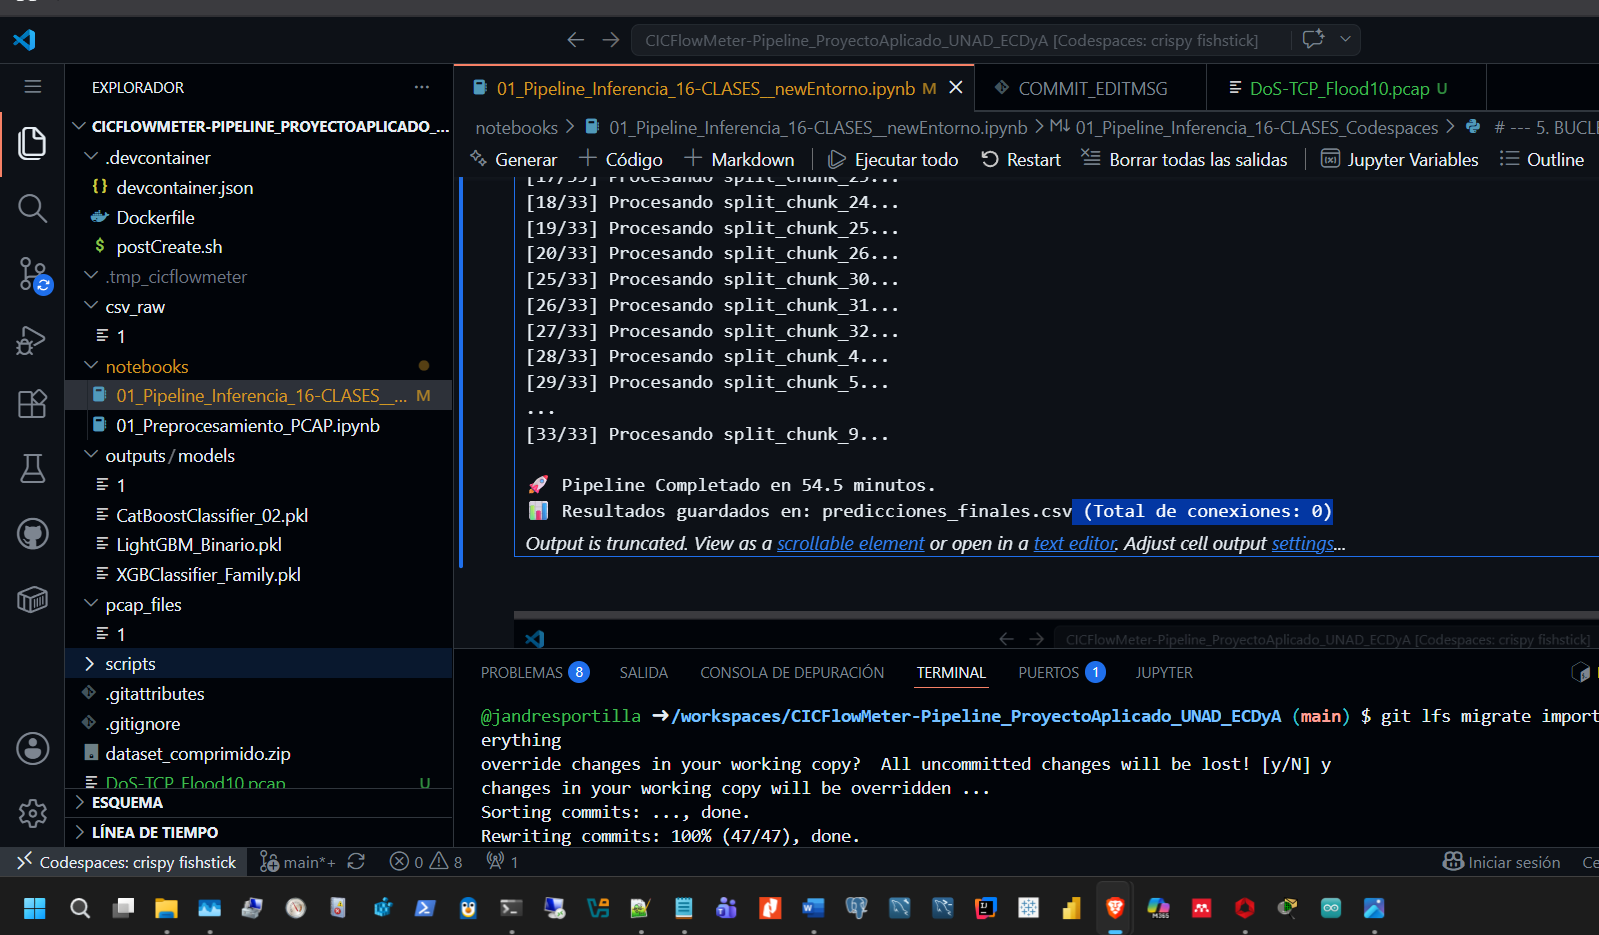

El warning de DivisionByZero en bulk_rate es inofensivo, solo significa que algunos flujos no tienen bulk traffic.



In [22]:
#    8e.)  También parchear el DivisionByZero en flow_bytes.py
import site
from pathlib import Path

for sp in site.getsitepackages():
    fb = Path(sp) / 'cicflowmeter' / 'features' / 'flow_bytes.py'
    if not fb.exists():
        continue
    src = fb.read_text()
    OLD = "self.feature.forward_bulk_size / self.feature.forward_bulk_duration"
    NEW = ("self.feature.forward_bulk_size / self.feature.forward_bulk_duration"
           " if self.feature.forward_bulk_duration != 0 else 0")
    if OLD in src and NEW not in src:
        fb.write_text(src.replace(OLD, NEW))
        print(f"✓ DivisionByZero parchado en {fb.name}")
    break

**Por fin Superado, 0MB, Generaba un Archivo Vacio, por enter, NO ESCRIBIA, NO WRITER**

**Ya de nuevo, genero los Flujos de Trafico, correcto Cicflowmeter, y correcta la genracion del Dataset .CSV**

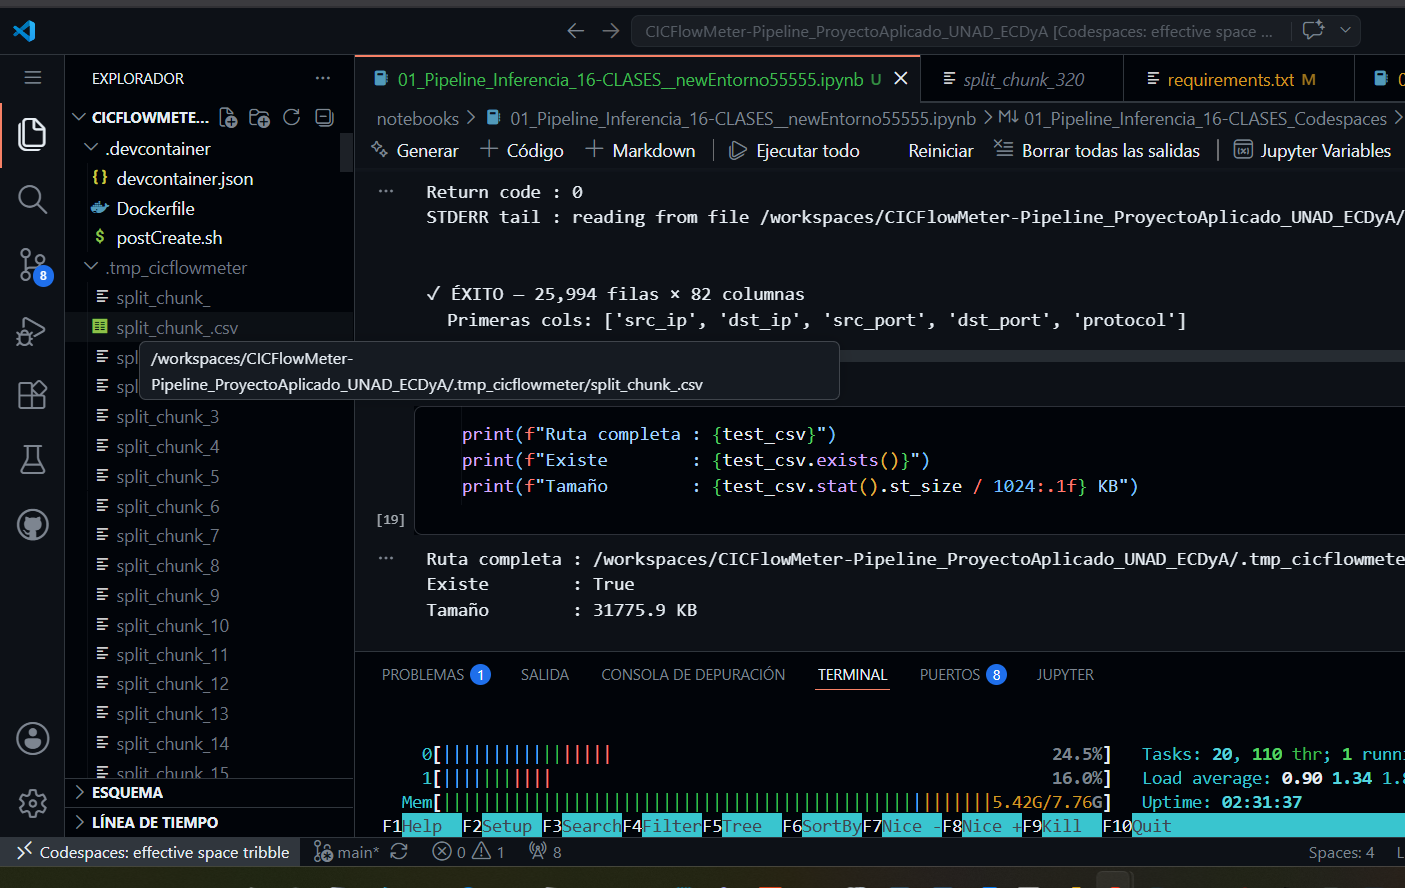

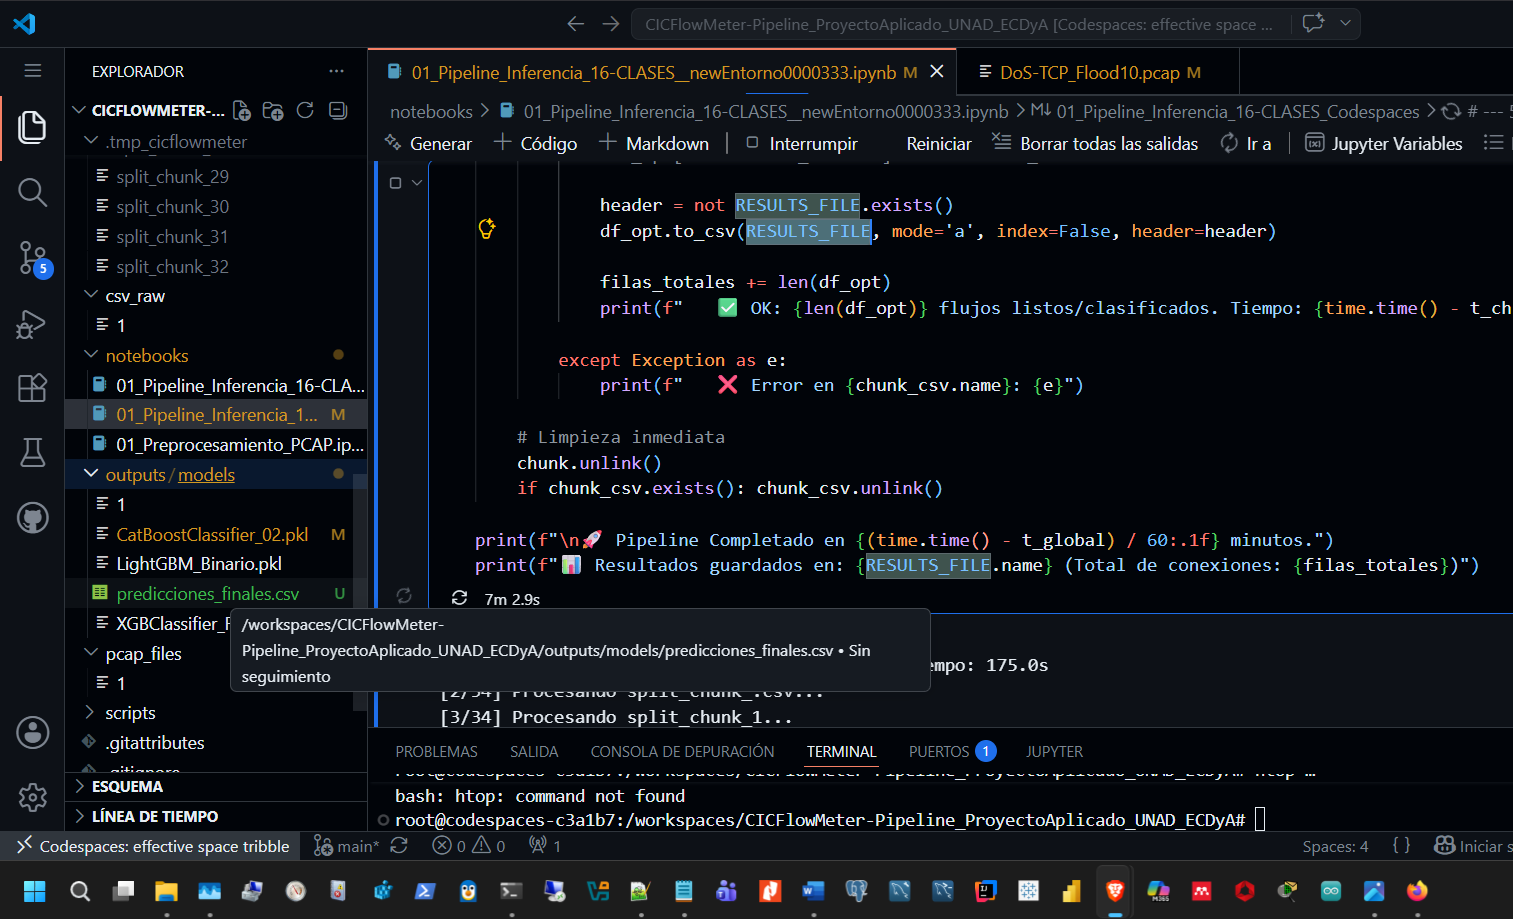

## **EL MOTOR STREAMING Y DASHBOARD IDS CON EL MODELO PREDICTOR CATBOOST EN VIVO Y EN LA NUBE CODESPACE**

## Detrás de Escena, tras Bambalinas 

1.  `clear_output(wait=True)`: Es el alma de este script. **Borra la celda un microsegundo antes de que Python termine de dibujar el nuevo gráfico**. Esto evita que tu pantalla se llene de cientos de gráficos hacia abajo, *manteniendo un único panel que se actualiza animadamente*.

2.  Lectura Ligera: Se usa `pd.read_csv` sobre el archivo de resultados incremental. Como filtramos todo a solo 40 atributos numéricos altamente optimizados (int32, float32), Pandas puede leer y graficar los datos en milisegundos, manteniendo la UI completamente fluida.

3.  Muestra Dinámica `df_dash.tail(8)`: En lugar de mostrar valores aleatorios globales, te muestra literalmente **los últimos 8 paquetes de red (flujos)** que acaban de ser **procesados y etiquetados por el modelo CatBoost**, con la idea de un efecto real de sistema de Monitoreo de IDS Sistema de Detección de Intrusos.

/usr/local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


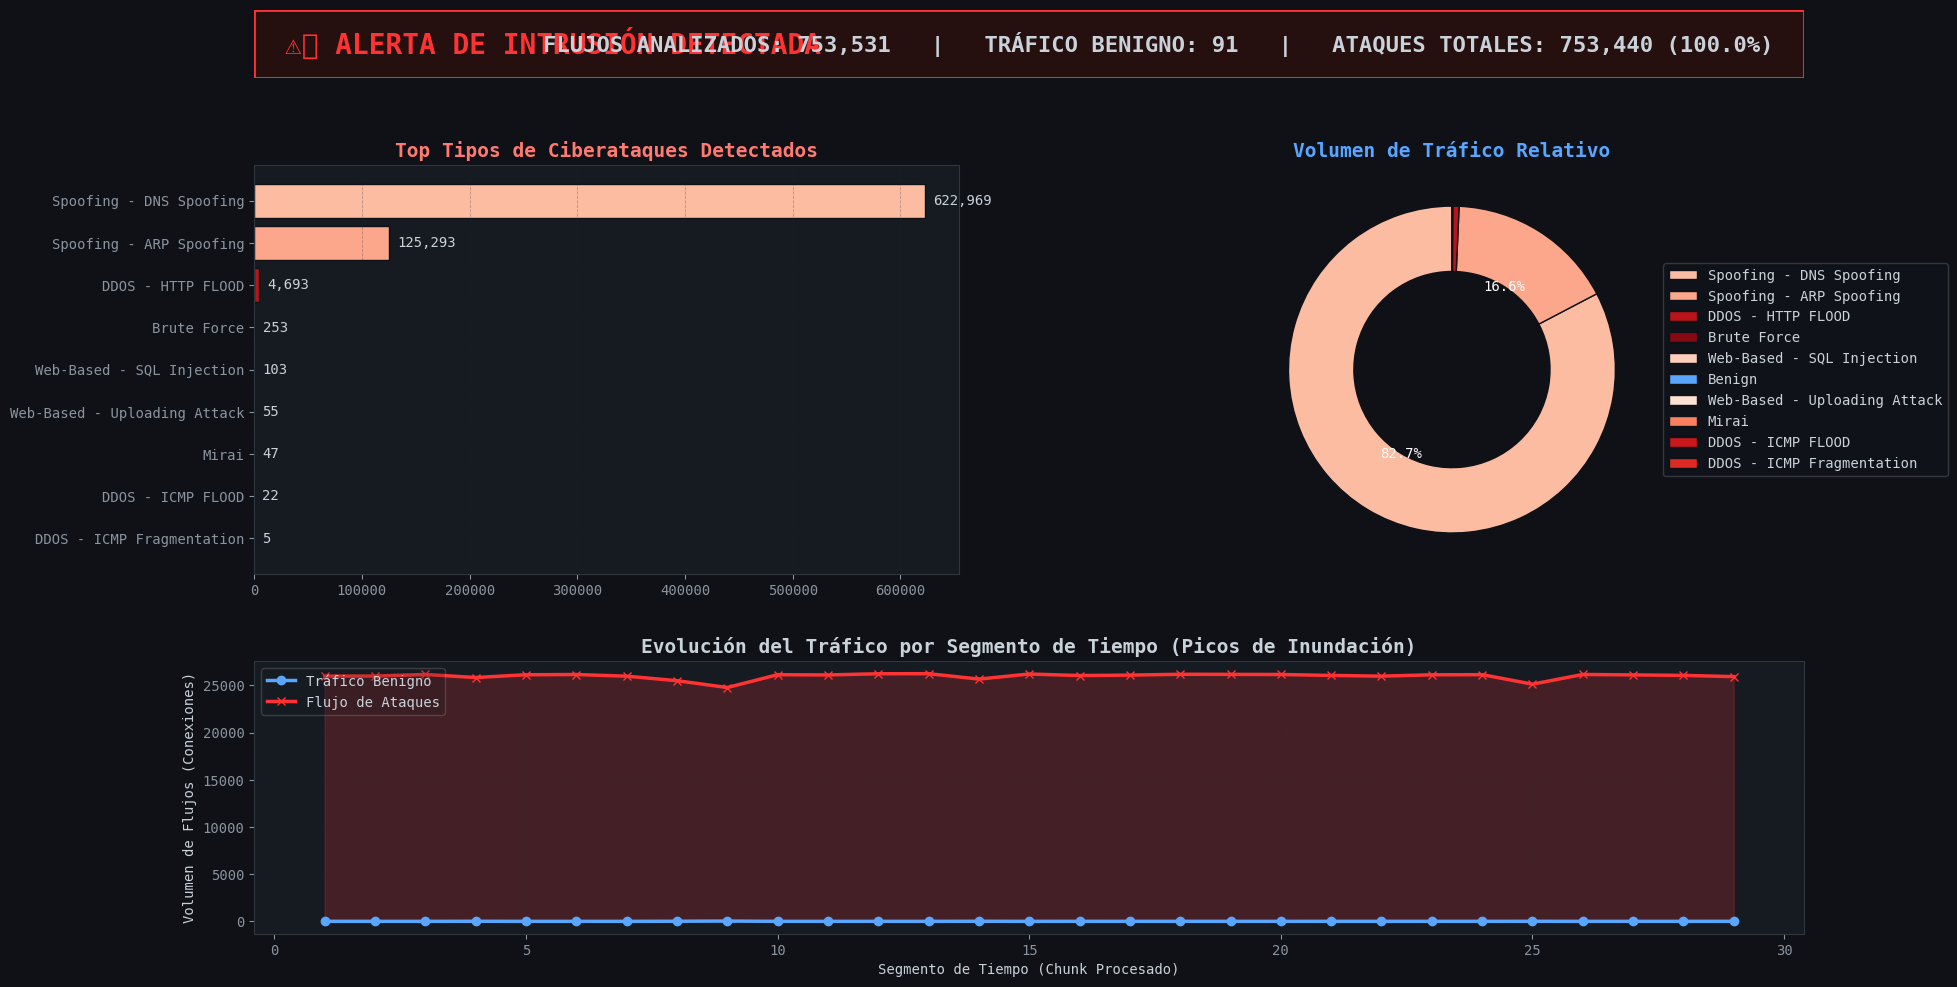


[29/321] 🔍 ÚLTIMOS FLUJOS REGISTRADOS:


/tmp/ipykernel_96099/3217621334.py:159: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  display(muestra.style


,Src Port,Dst Port,Protocol,Flow Packets/s,Nombre_Ataque
753525,10403,443,6,0.000000,Spoofing - DNS Spoofing
753526,10404,443,6,0.000000,Spoofing - DNS Spoofing
753527,10405,443,6,0.000000,Spoofing - DNS Spoofing
753528,10406,443,6,0.000000,Spoofing - DNS Spoofing
753529,10407,443,6,0.000000,Spoofing - DNS Spoofing
753530,10408,443,6,0.000000,Spoofing - DNS Spoofing


: 

In [28]:
#   9.)   BUCLE DE EXTRACCIÓN Y PREDICCIÓN AL VUELO, MICRO.CSV POR MICRO.CSV
 
for idx, chunk in enumerate(chunks):
    chunk_csv = chunk.with_suffix(".csv")
    

    #  EXTRACCIÓN 
    subprocess.run(["cicflowmeter", "-f", str(chunk), "-c", str(chunk_csv)], capture_output=True)
    
    if chunk_csv.exists() and chunk_csv.stat().st_size > 100:
        try:
            df_tmp = pd.read_csv(chunk_csv, low_memory=False)
            df_tmp.columns = df_tmp.columns.str.strip()
            
            df_renamed = pd.DataFrame()
            for k, v in MAPEO.items():
                if k in df_tmp.columns: df_renamed[v] = df_tmp[k].values
            
            for col in COLS_40:
                if col not in df_renamed.columns: df_renamed[col] = 0
                    
            df_opt = df_renamed[COLS_40].copy()
            df_opt.replace([np.inf, -np.inf, "inf", "-inf", "Infinity", "-Infinity"], np.nan, inplace=True)
            df_opt.dropna(subset=["Flow Bytes/s", "Flow Packets/s"], inplace=True)
            
            if df_opt.empty: continue
            
            for col in COLS_40:
                if col in COLS_INT32:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0).astype(np.int32)
                else:
                    df_opt[col] = pd.to_numeric(df_opt[col], errors='coerce').fillna(0.0).astype(np.float32)


            #  INFERENCIA Y TRADUCCIÓN 
            pred_numericas = modelo.predict(df_opt)
            # Aseguramos que sea entero y mapeamos al nombre real del ataque
            pred_numericas = np.array(pred_numericas).flatten().astype(int)
            df_opt['Clase_ID'] = pred_numericas
            df_opt['Nombre_Ataque'] = df_opt['Clase_ID'].map(inv_mapping)
            

            # Etiquetar el paso del tiempo para el gráfico de línea
            df_opt['Chunk_ID'] = idx + 1 
            

            #  GUARDADO INCREMENTAL 
            header = not RESULTS_FILE.exists()
            df_opt.to_csv(RESULTS_FILE, mode='a', index=False, header=header)
            

            
            # --- DASHBOARD SOC (IDS) VISUALIZACIÓN ---
            
            df_dash = pd.read_csv(RESULTS_FILE, low_memory=False)
            n_total = len(df_dash)
            

            # Cálculos de KPI Críticos
            conteo_clases = df_dash["Nombre_Ataque"].value_counts()
            n_benign = conteo_clases.get("Benign", 0)
            n_attacks = n_total - n_benign
            pct_attacks = (n_attacks / n_total) * 100 if n_total > 0 else 0
            
            clear_output(wait=True)
            

            # Creación de la Estructura (GridSpec)
            fig = plt.figure(figsize=(20, 12), facecolor="#0F1117")
            gs = gridspec.GridSpec(3, 2, height_ratios=[0.5, 3, 2], wspace=0.2, hspace=0.35)
            

            #  [SUBPLOT 1] MÓDULO KPI TOTALIZADOR (EL BANNER) 
            ax_kpi = fig.add_subplot(gs[0, :])
            ax_kpi.axis('off')
            

            # Lógica de Alerta
            if n_attacks > 0:
                bg_color, edge_color, alert_text = "#250F0F", "#FF3333", f"⚠️ ALERTA DE INTRUSIÓN DETECTADA"
            else:
                bg_color, edge_color, alert_text = "#0B1D12", "#3FB950", "✅ TRÁFICO NORMAL"
                
            ax_kpi.add_patch(plt.Rectangle((0, 0), 1, 1, facecolor=bg_color, edgecolor=edge_color, linewidth=2, transform=ax_kpi.transAxes))
            ax_kpi.text(0.02, 0.5, alert_text, fontsize=20, fontweight="bold", color=edge_color, va="center", transform=ax_kpi.transAxes)
            

            # Textos Totalizadores
            kpi_text = (f"FLUJOS ANALIZADOS: {n_total:,}   |   "
                        f"TRÁFICO BENIGNO: {n_benign:,}   |   "
                        f"ATAQUES TOTALES: {n_attacks:,} ({pct_attacks:.1f}%)")
            ax_kpi.text(0.98, 0.5, kpi_text, fontsize=16, fontweight="bold", color="#C9D1D9", va="center", ha="right", transform=ax_kpi.transAxes)
            

            #  [SUBPLOT 2] DISTRIBUCIÓN DE ATAQUES (BARRAS HORIZONTALES) 
            ax_bar = fig.add_subplot(gs[1, 0])

            # Filtramos para no opacar los ataques con el tráfico benigno si este es muy grande
            df_ataques = conteo_clases.drop("Benign", errors="ignore")
            
            if not df_ataques.empty:
                colores_barras = [COLOR_MAP.get(x, "#FFFFFF") for x in df_ataques.index]
                bars = ax_bar.barh(df_ataques.index.astype(str), df_ataques.values, color=colores_barras, edgecolor="#0F1117")
                for bar, cnt in zip(bars, df_ataques.values):
                    ax_bar.text(bar.get_width() + (n_attacks*0.01), bar.get_y() + bar.get_height()/2, 
                                f"{cnt:,}", va="center", color="#C9D1D9", fontsize=10)
            ax_bar.set_title("Top Tipos de Ciberataques Detectados", color="#FF7B72", fontweight="bold", fontsize=14)
            ax_bar.invert_yaxis()
            ax_bar.grid(axis="x", alpha=0.3)
            


            #  [SUBPLOT 3] PROPORCIÓN (DONUT)
            ax_pie = fig.add_subplot(gs[1, 1])

            # Agrupamos para el pie: Benign vs Cada Ataque
            colores_pie = [COLOR_MAP.get(x, "#FFFFFF") for x in conteo_clases.index]
            wedges, _, autotexts = ax_pie.pie(conteo_clases.values, autopct=lambda p: f"{p:.1f}%" if p > 3 else "", 
                                           colors=colores_pie, startangle=90, wedgeprops={"width": 0.4, "edgecolor": "#0F1117"})
            for at in autotexts: at.set_color("#FFFFFF")
            ax_pie.legend(wedges, conteo_clases.index, loc="center left", bbox_to_anchor=(1, 0.5), fontsize=10)
            ax_pie.set_title("Volumen de Tráfico Relativo", color="#58A6FF", fontweight="bold", fontsize=14)
            
            
            #  [SUBPLOT 4] TIMELINE: PICOS DE TRÁFICO (LÍNEA DE TIEMPO) 
            ax_line = fig.add_subplot(gs[2, :])
            # Agrupar por Chunk_ID para simular la línea de tiempo
            timeline = df_dash.groupby(['Chunk_ID', 'Nombre_Ataque']).size().unstack(fill_value=0)
            
            if "Benign" in timeline.columns:
                ax_line.plot(timeline.index, timeline["Benign"], color=COLOR_BENIGN, label="Tráfico Benigno", linewidth=2.5, marker="o")
            

            # Agrupar todos los ataques en una sola línea roja para el timeline de intrusiones
            ataques_cols = [c for c in timeline.columns if c != "Benign"]
            if ataques_cols:
                timeline['Total_Ataques'] = timeline[ataques_cols].sum(axis=1)
                ax_line.plot(timeline.index, timeline['Total_Ataques'], color="#FF3333", label="Flujo de Ataques", linewidth=2.5, marker="x")
                ax_line.fill_between(timeline.index, 0, timeline['Total_Ataques'], color="#FF3333", alpha=0.2)
                

            ax_line.set_title("Evolución del Tráfico por Segmento de Tiempo (Picos de Inundación)", color="#C9D1D9", fontweight="bold", fontsize=14)
            ax_line.set_ylabel("Volumen de Flujos (Conexiones)")
            ax_line.set_xlabel("Segmento de Tiempo (Chunk Procesado)")
            ax_line.legend(loc="upper left")
            ax_line.grid(alpha=0.2)
            
            plt.show()
            

            #  TABLA DE REGISTROS CRÍTICOS (LOG EN VIVO) 
            print(f"\n[{idx+1}/{len(chunks)}] 🔍 ÚLTIMOS FLUJOS REGISTRADOS:")
            cols_show = ["Src Port", "Dst Port", "Protocol", "Flow Packets/s", "Nombre_Ataque"]
            cols_ok = [c for c in cols_show if c in df_dash.columns]
            muestra = df_dash.tail(6)[cols_ok]
            

            # Estilizar con Azul y Rojo puro
            display(muestra.style
                    .set_properties(**{"font-size": "12px", "background-color": "#161B22", "border": "1px solid #30363D"})
                    .applymap(lambda v: "color: #58A6FF; font-weight:bold" if str(v) == "Benign" else "color: #FF3333; font-weight:bold", subset=["Nombre_Ataque"]))

        except Exception as e:
            print(f"⚠️ Aviso en {chunk_csv.name}: {e}")
            

    chunk.unlink()
    if chunk_csv.exists(): chunk_csv.unlink()


print("ANÁLISIS DE PARTE DEL OBETIVO 3 - MUESTRAS NUNCA ANTES VISTAS, EJEMPLOS DE PREDICCIÓN COMPLETADO EXITOSAMENTE")
print("Modelo predictivo para clasificación multiclase de ataques de intrusión en redes IoT mediante técnicas de machine learningE")
print("Especialización en Ciencia de Datos y Analítica")
print("Escuela de Ciencias Básicas, Tecnología e Ingeniería ECBTI")
print("Universidad Nacional Abierta y a Distancia UNAD")

**El Primer Dashboard, Falta el Mapeo de Ataques de Nuemeros a Nombre**

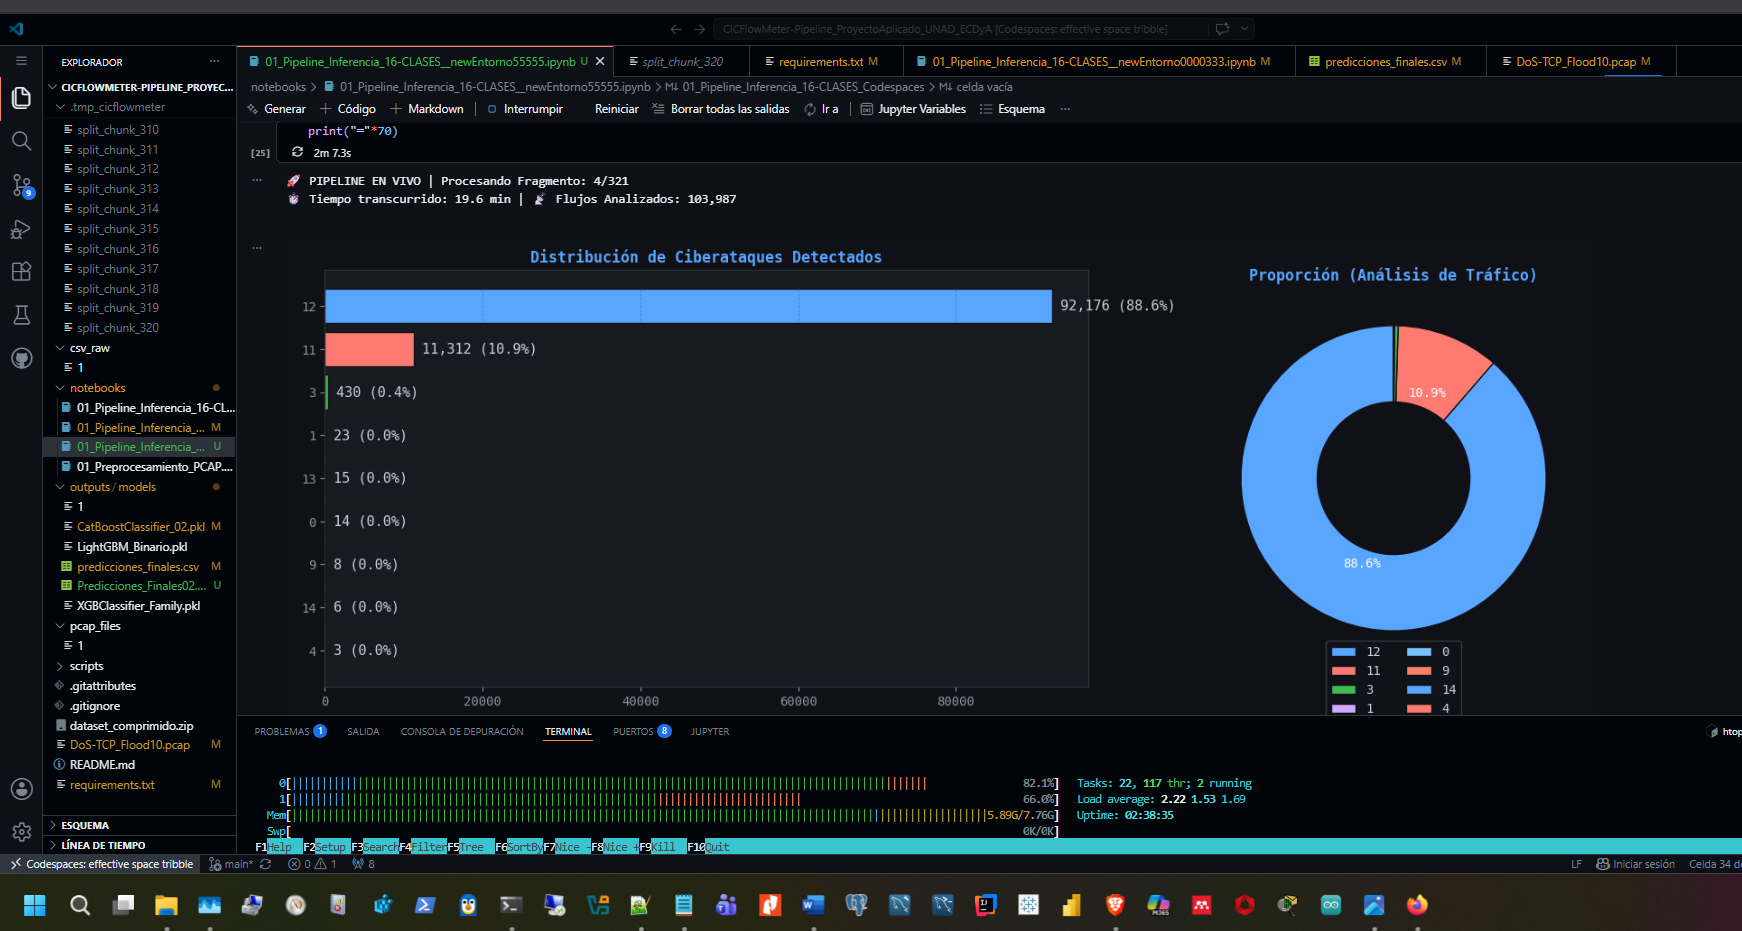

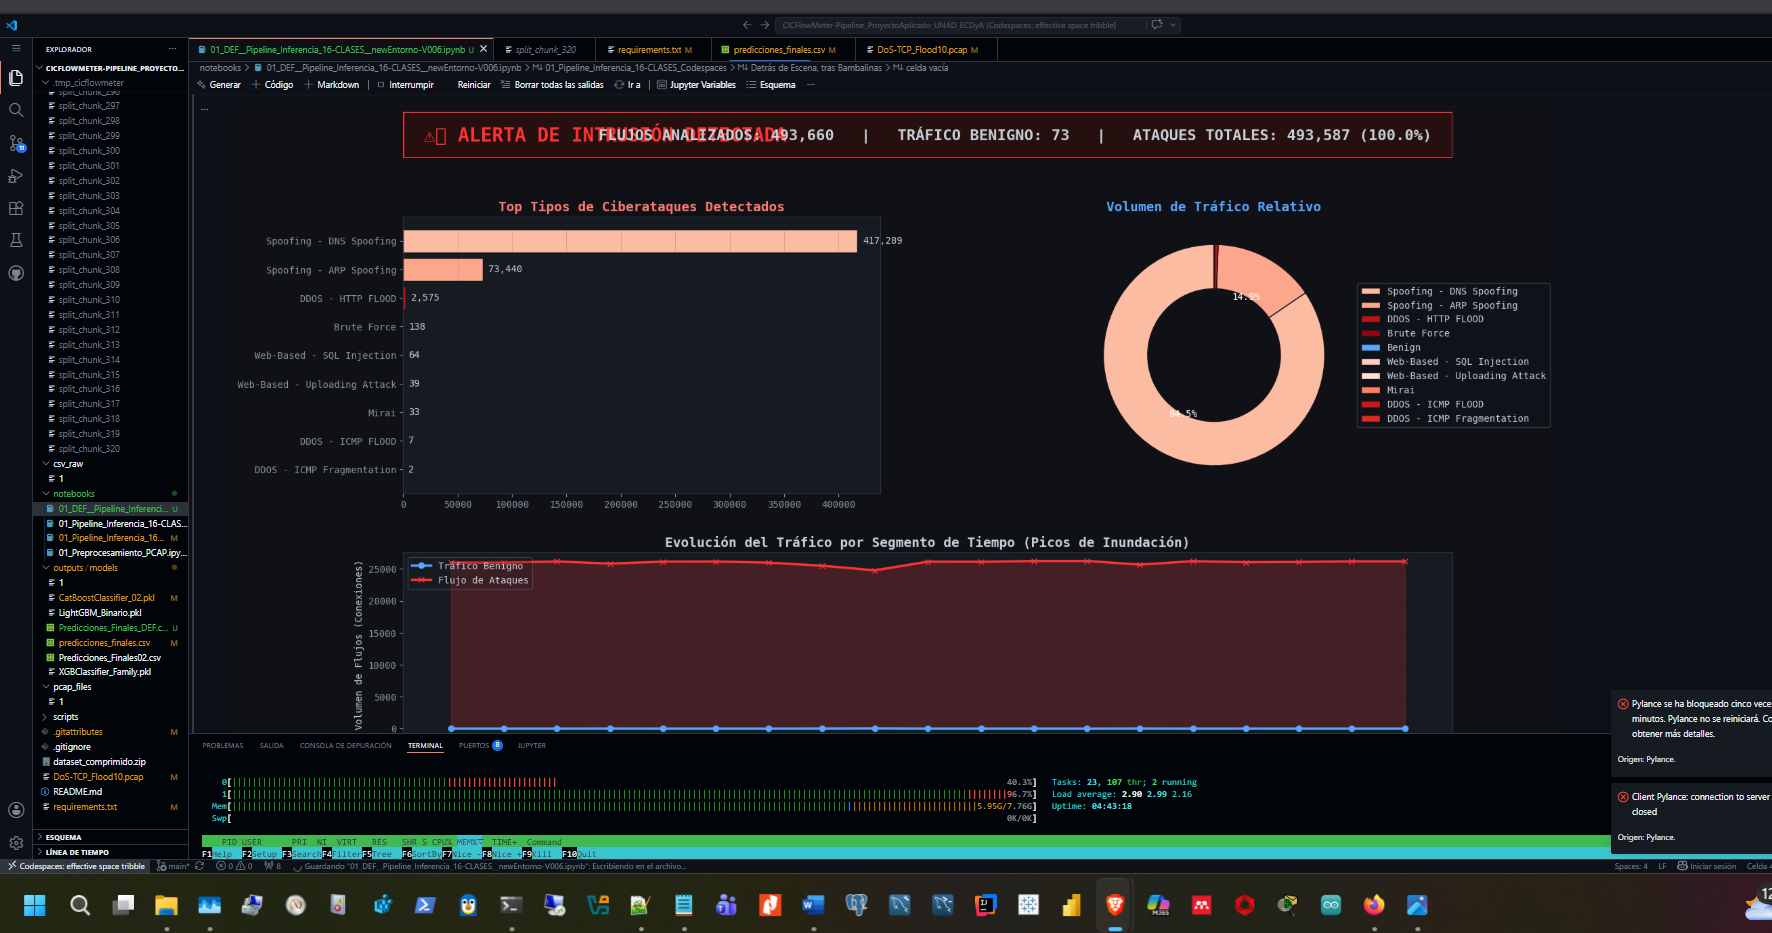

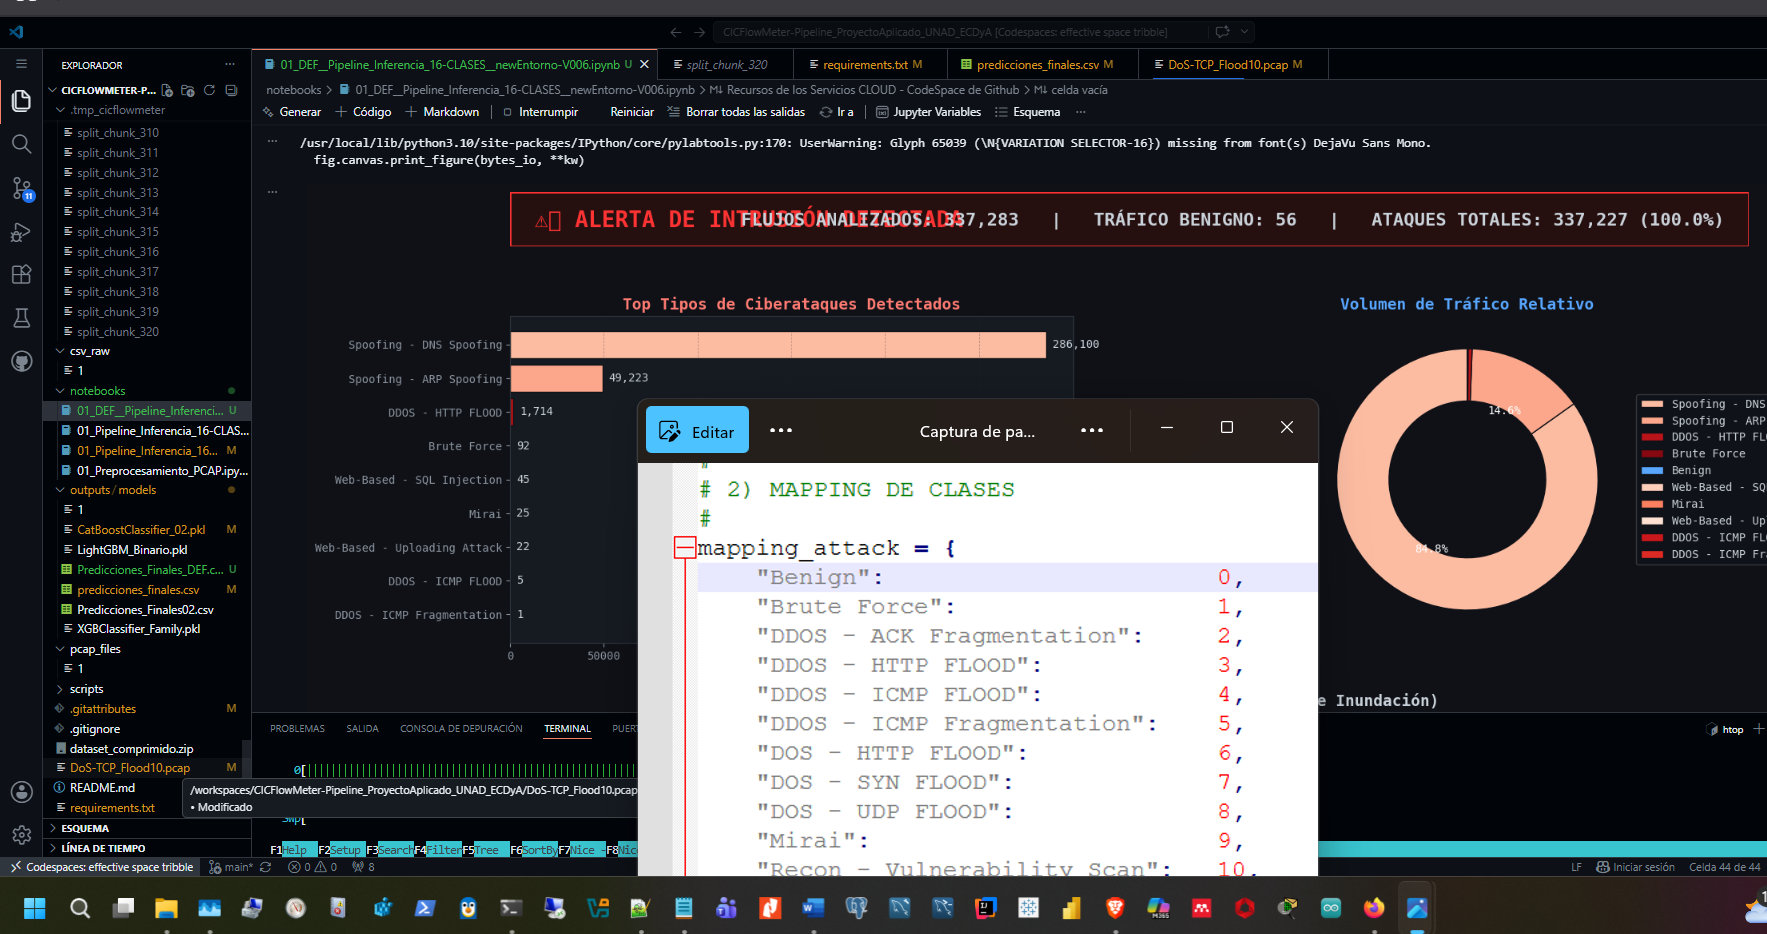

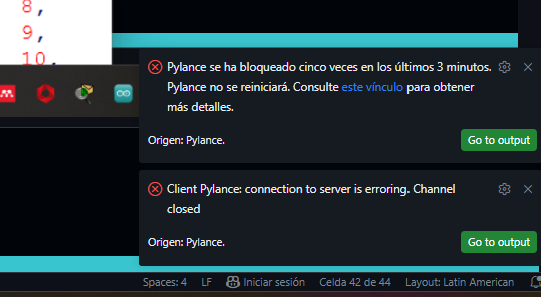

# Recursos de los Servicios CLOUD - CodeSpace de Github

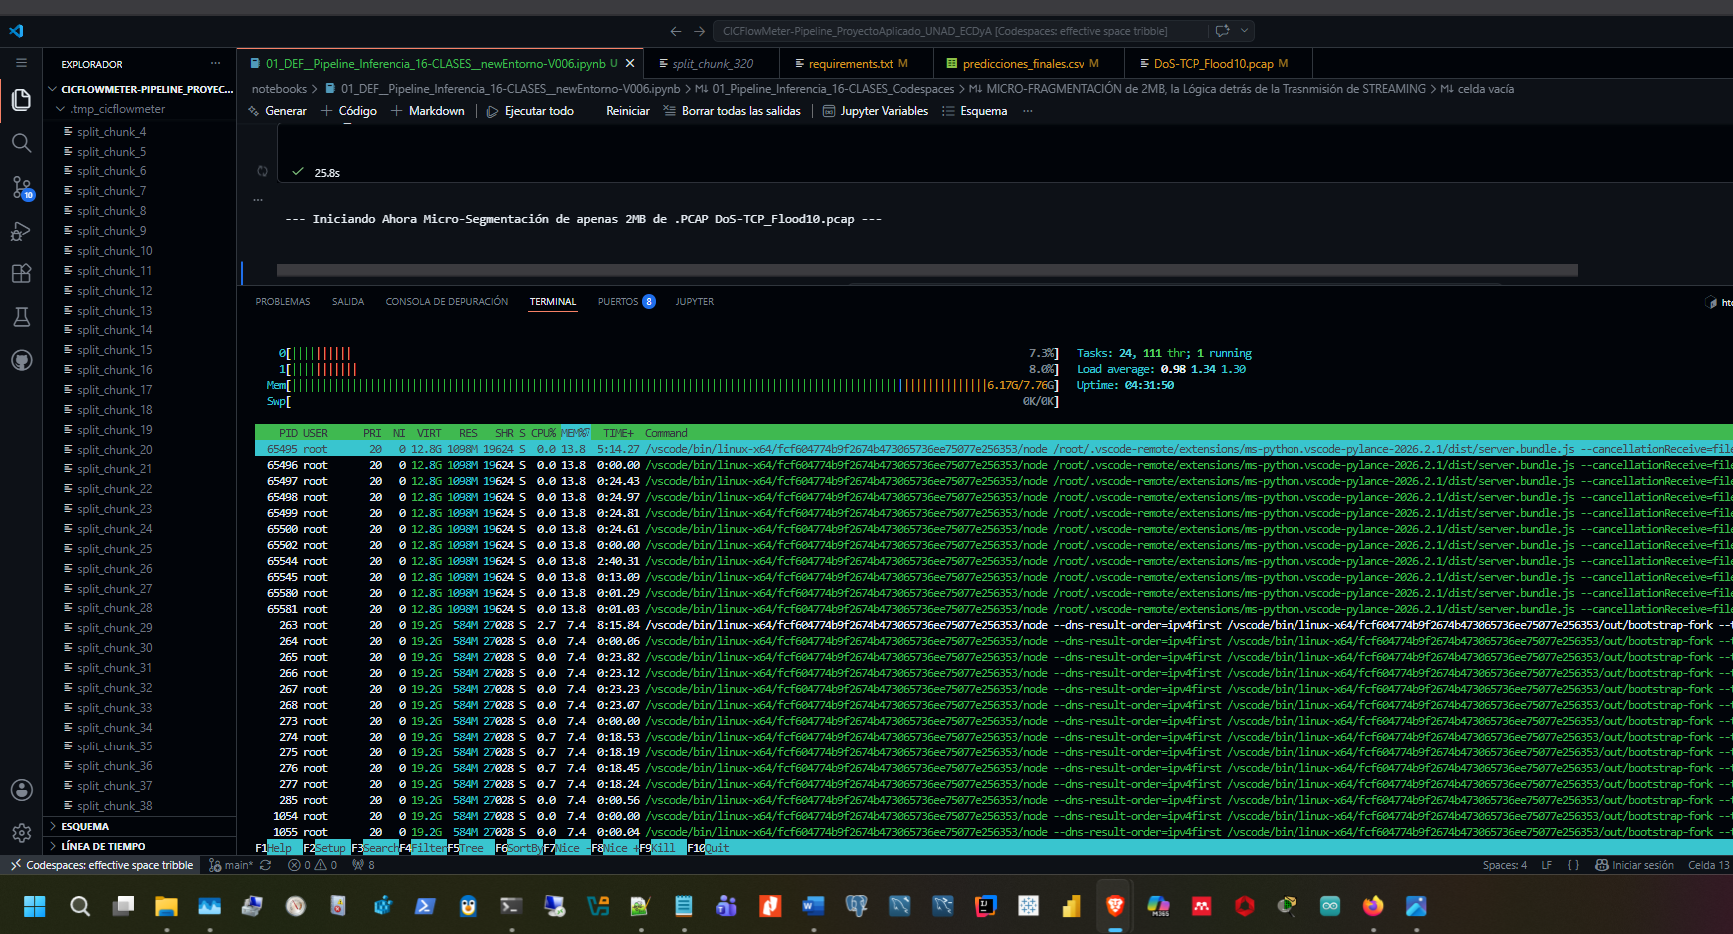